# FINANCE 384 

## Lecture 1: Welch and Goyal Style Return Prediction

This notebook introduces a first empirical finance workflow using the Welch-Goyal predictor data. We compare a simple predictive regression with a historical-average benchmark.

## Learning objectives

After completing this notebook, you should be able to:

1. load an Excel dataset with pandas;
2. construct a dividend-price predictor and an equity-premium target;
3. explain why the predictor must be known before the return is realized;
4. fit a simple regression using sklearn;
5. compare forecasts with a historical-mean benchmark;
6. calculate RMSE, MAE, bias, and out-of-sample \(R^2\);
7. interpret the results as evidence for a financial decision.


## 1. Imports and settings

This notebook uses the packages pandas, NumPy, sklearn and Matplotlib. 


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True


## 2. Locate the data file

The workbook is stored in the Topic 0 source material folder. The path logic below works both when the notebook is run from `Topic0_Introduction/4.Code` and when it is run from the project root.


In [2]:

data_path = "PredictorData2023.xlsx"

data_path


'PredictorData2023.xlsx'

## 3. Load the annual sheet

The workbook contains monthly, quarterly, and annual sheets. We use annual data to keep the first application compact and close to the simple Goyal-Welch teaching example.


In [3]:
annual = pd.read_excel(data_path, sheet_name="Annual")

annual.head()


,yyyy,Index,D12,E12,b/m,tbl,AAA,BAA,lty,cay,...,Rfree,infl,eqis,ltr,corpr,svar,csp,ik,CRSP_SPvw,CRSP_SPvwx
0,1871,4.74,0.26,0.40,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1872,5.07,0.30,0.43,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1873,4.42,0.33,0.46,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1874,4.54,0.33,0.46,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1875,4.37,0.30,0.36,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
annual.shape, annual.columns.tolist()


((153, 21),
 ['yyyy',
  'Index',
  'D12',
  'E12',
  'b/m',
  'tbl',
  'AAA',
  'BAA',
  'lty',
  'cay',
  'ntis',
  'Rfree',
  'infl',
  'eqis',
  'ltr',
  'corpr',
  'svar',
  'csp',
  'ik',
  'CRSP_SPvw',
  'CRSP_SPvwx'])

## 4. Parse dates and construct variables

We create:

- `dividend_price`: \(\log(D12_t) - \log(Index_t)\);
- `log_market_return`: log return on the market index including dividends;
- `log_risk_free`: log risk-free return;
- `equity_premium`: market return minus risk-free return;
- `equity_premium_next_year`: next year's equity premium, the prediction target.

The key timing convention is:

$x_t \quad \text{predicts} \quad r_{t+1}.$


In [5]:
annual = annual.copy()
annual["date"] = pd.to_datetime(annual["yyyy"].astype(str), format="%Y")
annual["date"] = annual["date"].dt.to_period("Y").dt.to_timestamp("Y")
annual = annual.set_index("date").sort_index()

annual["dividend_price"] = np.log(annual["D12"]) - np.log(annual["Index"])
annual["log_market_return"] = np.log((annual["Index"] + annual["D12"]) / annual["Index"].shift(1))
annual["log_risk_free"] = np.log1p(annual["Rfree"])
annual["equity_premium"] = annual["log_market_return"] - annual["log_risk_free"]
annual["equity_premium_next_year"] = annual["equity_premium"].shift(-1)

analysis = annual[["dividend_price", "equity_premium_next_year"]].dropna().copy()
analysis.head()


,dividend_price,equity_premium_next_year
date,,
1871-12-31,-2.9031,0.0533
1872-12-31,-2.8273,-0.1529
1873-12-31,-2.5948,0.0403
1874-12-31,-2.6216,-0.0166
1875-12-31,-2.6787,-0.1620


In [6]:
analysis.tail()


,dividend_price,equity_premium_next_year
date,,
2018-12-31,-3.8425,0.2495
2019-12-31,-4.0159,0.1608
2020-12-31,-4.1659,0.2503
2021-12-31,-4.3684,-0.2117
2022-12-31,-4.0496,0.1833


## 5. Inspect the variables

Before modelling, plot and summarize the predictor and target.


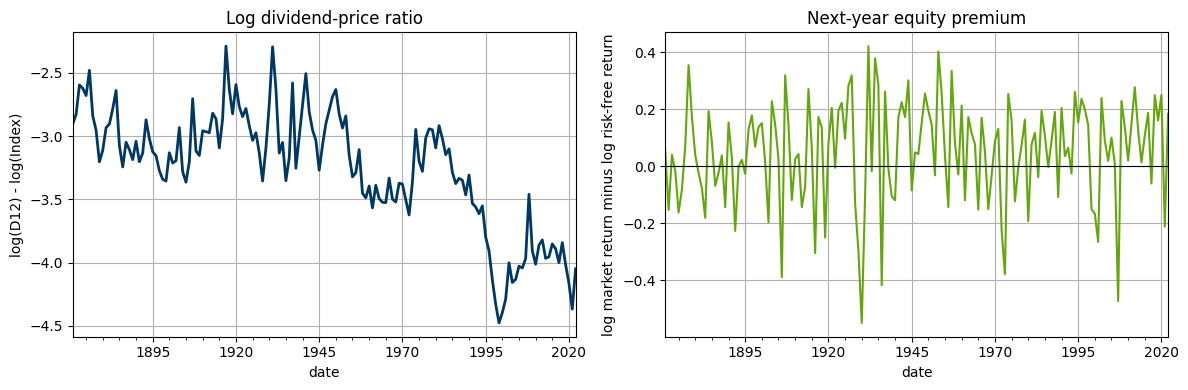

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

analysis["dividend_price"].plot(ax=axes[0], color="#003865", linewidth=2)
axes[0].set_title("Log dividend-price ratio")
axes[0].set_ylabel("log(D12) - log(Index)")

analysis["equity_premium_next_year"].plot(ax=axes[1], color="#64A70B", linewidth=1.5)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Next-year equity premium")
axes[1].set_ylabel("log market return minus log risk-free return")

plt.tight_layout()
plt.show()


In [8]:
analysis.describe()


,dividend_price,equity_premium_next_year
count,152.0000,152.0000
mean,-3.2503,0.0512
std,0.4643,0.1785
min,-4.4776,-0.5496
25%,-3.4946,-0.0435
50%,-3.1539,0.0731
75%,-2.9327,0.1727
max,-2.2880,0.4214


## 6. A simple linear regression with scikit-learn

For a regression

$y = \alpha + \beta x + \varepsilon$,

we use scikit-learn's `LinearRegression`.

scikit-learn estimators share a common interface: create the estimator, call `.fit(X, y)` to estimate the coefficients, and `.predict(X)` to generate forecasts. The same `fit`/`predict` pattern reappears for richer models later in the course.

One requirement: scikit-learn expects the feature matrix `X` to be two-dimensional, with one column per feature. For a single predictor we therefore pass `analysis[[predictor]]` (a DataFrame, note the double brackets), not `analysis[predictor]` (a Series). After fitting, the estimated intercept is `model.intercept_` ($\alpha$) and the slope is `model.coef_[0]` ($\beta$).

In [9]:
from sklearn.linear_model import LinearRegression

predictor = "dividend_price"
target = "equity_premium_next_year"

# Demonstration on the full sample. X must be 2D (a DataFrame), y is 1D.
demo_model = LinearRegression()
demo_model.fit(analysis[[predictor]], analysis[target])

# Estimated intercept (alpha) and slope (beta)
demo_model.intercept_, demo_model.coef_[0]

(np.float64(0.1367773282950214), np.float64(0.026324243311877604))

## 7. In-sample fit

In-sample fit asks how well the fitted line describes the data used to estimate it. This is useful, but it is not the same as a forecasting test.


In [10]:
model = LinearRegression()
model.fit(analysis[[predictor]], analysis[target])

analysis["in_sample_prediction"] = model.predict(analysis[[predictor]])
analysis["historical_mean_prediction"] = analysis[target].mean()

alpha, beta = model.intercept_, model.coef_[0]
alpha, beta

(np.float64(0.1367773282950214), np.float64(0.026324243311877604))

In [11]:
def metric_table(actual, forecast, label):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    error = actual - forecast
    return pd.Series(
        {
            "RMSE": np.sqrt(np.mean(error**2)),
            "MAE": np.mean(np.abs(error)),
            "Bias: mean(actual - forecast)": np.mean(error),
        },
        name=label,
    )


in_sample_metrics = pd.concat(
    [
        metric_table(analysis[target], analysis["historical_mean_prediction"], "Historical mean"),
        metric_table(analysis[target], analysis["in_sample_prediction"], "Predictive regression"),
    ],
    axis=1,
).T

in_sample_metrics


,RMSE,MAE,Bias: mean(actual - forecast)
Historical mean,0.1780,0.1404,0.0000e+00
Predictive regression,0.1775,0.1405,5.8433e-18


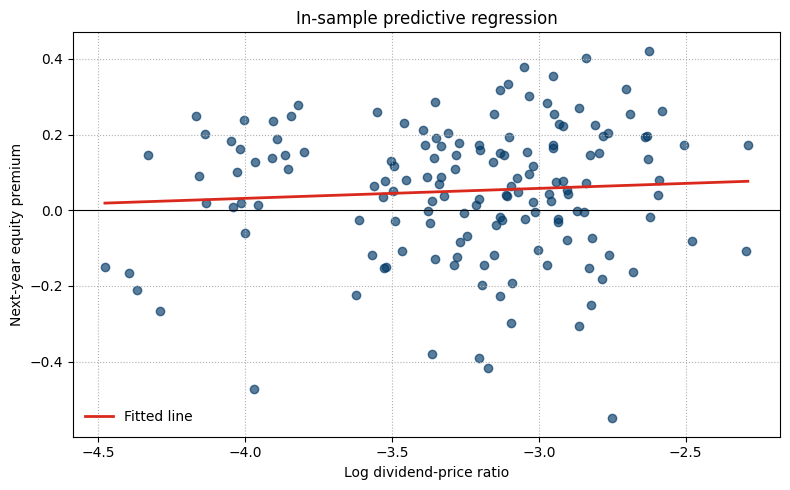

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(analysis[predictor], analysis[target], alpha=0.65, color="#003865")

x_grid = np.linspace(analysis[predictor].min(), analysis[predictor].max(), 100)
grid = pd.DataFrame({predictor: x_grid})
y_grid = model.predict(grid)
ax.plot(x_grid, y_grid, color="#DA291C", linewidth=2, label="Fitted line")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("In-sample predictive regression")
ax.set_xlabel("Log dividend-price ratio")
ax.set_ylabel("Next-year equity premium")
ax.grid(True, linestyle=":")
ax.legend(loc="lower left", frameon=False)

plt.tight_layout()
plt.show()

## 8. Expanding-window out-of-sample forecasts

Out-of-sample forecasting is stricter. At each date, we estimate the model only with information available up to that point, then forecast the next observation.

Benchmark forecast: historical average equity premium using the available history.

Model forecast: expanding-window OLS forecast using the dividend-price ratio.


In [13]:
def expanding_window_forecast(data, predictor, target, initial_window=20):
    records = []

    for i in range(initial_window, len(data)):
        train = data.iloc[:i]
        test = data.iloc[i]

        benchmark_forecast = train[target].mean()

        # Fit a fresh regression on the history available at this date only.
        model = LinearRegression()
        model.fit(train[[predictor]], train[target])

        # Forecast the next observation. Pass a 1-row DataFrame so the feature
        # names match those seen during fit.
        test_X = data.iloc[[i]][[predictor]]
        model_forecast = model.predict(test_X)[0]

        records.append(
            {
                "date": data.index[i],
                "actual": test[target],
                "historical_mean_forecast": benchmark_forecast,
                "model_forecast": model_forecast,
                "alpha": model.intercept_,
                "beta": model.coef_[0],
            }
        )

    forecasts = pd.DataFrame(records).set_index("date")
    forecasts["benchmark_error"] = forecasts["actual"] - forecasts["historical_mean_forecast"]
    forecasts["model_error"] = forecasts["actual"] - forecasts["model_forecast"]
    forecasts["squared_error_difference"] = (
        forecasts["benchmark_error"] ** 2 - forecasts["model_error"] ** 2
    )
    forecasts["cumulative_sse_difference"] = forecasts["squared_error_difference"].cumsum()

    return forecasts


forecasts = expanding_window_forecast(analysis, predictor, target, initial_window=20)
forecasts.head()

,actual,historical_mean_forecast,model_forecast,alpha,beta,benchmark_error,model_error,squared_error_difference,cumulative_sse_difference
date,,,,,,,,,
1891-12-31,0.0289,0.0136,0.0423,-0.2709,-0.0978,0.0153,-0.0134,5.5645e-05,5.5645e-05
1892-12-31,-0.2271,0.0143,0.0342,-0.2608,-0.0941,-0.2414,-0.2613,-9.9894e-03,-9.9338e-03
1893-12-31,-0.0017,0.0034,0.0006,-0.1279,-0.0448,-0.0051,-0.0023,2.0412e-05,-9.9134e-03
1894-12-31,0.0223,0.0032,0.0072,-0.1284,-0.0449,0.0192,0.0152,1.3837e-04,-9.7750e-03
1895-12-31,-0.0269,0.0040,0.0127,-0.1313,-0.0461,-0.0308,-0.0396,-6.1982e-04,-1.0395e-02


Positive values of `squared_error_difference` mean the predictive regression had a smaller squared error than the historical-mean benchmark for that observation. Negative values mean the benchmark was better.


In [14]:
oos_metrics = pd.concat(
    [
        metric_table(
            forecasts["actual"],
            forecasts["historical_mean_forecast"],
            "Historical mean",
        ),
        metric_table(
            forecasts["actual"],
            forecasts["model_forecast"],
            "Expanding-window predictive regression",
        ),
    ],
    axis=1,
).T

mse_benchmark = np.mean(forecasts["benchmark_error"] ** 2)
mse_model = np.mean(forecasts["model_error"] ** 2)
oos_r2 = 1 - mse_model / mse_benchmark

oos_metrics["OOS R2 vs historical mean"] = [np.nan, oos_r2]
oos_metrics


,RMSE,MAE,Bias: mean(actual - forecast),OOS R2 vs historical mean
Historical mean,0.1852,0.1476,0.0204,NaN
Expanding-window predictive regression,0.1871,0.1506,0.0333,-0.0201


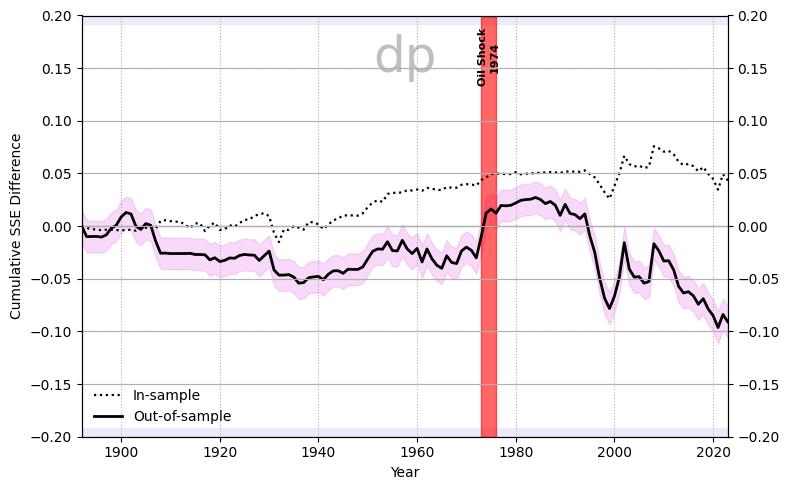

In [15]:
# Welch-Goyal style figure: cumulative squared-error difference,
# benchmark (prevailing mean) minus model. Above zero the regression is
# ahead; below zero the prevailing mean is. Dotted = in-sample, solid = out-of-sample.

# In-sample series: full-sample fit, cumulative squared errors (benchmark minus model)
is_error_benchmark = analysis[target] - analysis["historical_mean_prediction"]
is_error_model = analysis[target] - analysis["in_sample_prediction"]
is_cum = (is_error_benchmark ** 2).cumsum() - (is_error_model ** 2).cumsum()

# Out-of-sample series comes straight from the expanding-window forecasts
oos_cum = forecasts["cumulative_sse_difference"]

# Show the in-sample line only over the out-of-sample dates, rebased to zero
# at the first out-of-sample year (as in Welch and Goyal, 2008, Figure 1)
is_cum = is_cum.reindex(oos_cum.index)
is_cum = is_cum - is_cum.iloc[0]

fig, ax = plt.subplots(figsize=(8, 5))
ymin, ymax = -0.20, 0.20

# thin lavender margin bands at the top and bottom of the frame
ax.axhspan(ymax - 0.008, ymax, color="lavender", alpha=0.8, zorder=0)
ax.axhspan(ymin, ymin + 0.008, color="lavender", alpha=0.8, zorder=0)

# in-sample (dotted) and out-of-sample (solid), with a shaded band on the OOS line
ax.plot(is_cum.index, is_cum.values, linestyle=":", color="black",
        linewidth=1.6, label="In-sample")
ax.plot(oos_cum.index, oos_cum.values, color="black", linewidth=2.0,
        label="Out-of-sample")
ax.fill_between(oos_cum.index, oos_cum.values - 0.015, oos_cum.values + 0.015,
                color="violet", alpha=0.30)

# 1973-1975 Oil Shock
oil_lo, oil_hi = pd.Timestamp("1973-01-01"), pd.Timestamp("1975-12-31")
ax.axvspan(oil_lo, oil_hi, color="red", alpha=0.6)
ax.text(pd.Timestamp("1974-07-01"), ymax - 0.012, "Oil Shock\n1974",
        ha="center", va="top", rotation=90, weight="bold", fontsize=8)

# predictor label, like the panel titles in the paper
ax.text(0.5, 0.90, "dp", transform=ax.transAxes, ha="center", va="center",
        fontsize=36, alpha=0.25)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlim(oos_cum.index.min(), oos_cum.index.max())
ax.set_ylim(ymin, ymax)
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative SSE Difference")
ax.grid(True, linestyle=":")
ax.legend(loc="lower left", frameon=False)

ax2 = ax.twinx()          # mirror the y-axis on the right
ax2.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

## 9. Interpretation

Use the table and plots to answer:

1. Did the predictive regression beat the historical-average benchmark out of sample?
2. Was any improvement economically meaningful?
3. Did performance look stable through time?
4. What would you report to an investment committee?

Remember: a model that fits historical data well may still fail as a forecasting rule.


In [16]:
print(f"Out-of-sample R2 versus historical mean: {oos_r2:.4f}")

if oos_r2 > 0:
    print("The expanding-window predictive regression reduced out-of-sample MSE relative to the benchmark.")
else:
    print("The historical-mean benchmark had lower out-of-sample MSE than the predictive regression.")


Out-of-sample R2 versus historical mean: -0.0201
The historical-mean benchmark had lower out-of-sample MSE than the predictive regression.


## 9b. Comparison with the published Welch-Goyal results

Welch and Goyal (2008) report, for the dividend-price ratio at annual frequency over the full sample (1872-2005): in-sample $\bar R^2 = 0.49\%$ and out-of-sample $\bar R^2 = -2.06\%$ (Table 1 and the d/p summary on p. 1474).

Two points on comparability:

- The published $\bar R^2$ are degrees-of-freedom **adjusted**; the values above are **unadjusted**, and our data run to 2022 rather than 2005. The numbers are therefore close but not identical.
- The paper reports $\Delta$RMSE and $\bar R^2$, **not** raw RMSE, MAE, or bias. Those three metrics in the tables above have no published counterpart, so we compare $\Delta$RMSE instead.

The conclusion is the same either way: a tiny positive in-sample fit, and a **negative** out-of-sample $R^2$ — the dividend-price regression underperforms the prevailing-mean benchmark out of sample.

In [17]:
# Published Welch and Goyal (2008) values for the d/p predictor at annual
# frequency, full sample 1872-2005 (Table 1 and the d/p summary on p. 1474).
# These are degrees-of-freedom adjusted R-bar^2, in percent.
WG_IS_R2 = 0.49
WG_OOS_R2 = -2.06

# This notebook's values for the same predictor, annual, 1872-2022.
r2_is = model.score(analysis[[predictor]], analysis[target]) * 100      # unadjusted IS R^2
r2_oos = oos_r2 * 100                                                    # unadjusted OOS R^2
d_rmse = (np.sqrt(mse_benchmark) - np.sqrt(mse_model)) * 100            # Welch-Goyal dRMSE

comparison = pd.DataFrame(
    {
        "This notebook (1872-2022)": [r2_is, r2_oos, d_rmse],
        "Welch-Goyal 2008 (1872-2005)": [WG_IS_R2, WG_OOS_R2, np.nan],
    },
    index=["IS R2 (%)", "OOS R2 vs historical mean (%)", "dRMSE (% per year)"],
)
comparison.round(3)

,This notebook (1872-2022),Welch-Goyal 2008 (1872-2005)
IS R2 (%),0.469,0.49
OOS R2 vs historical mean (%),-2.010,-2.06
dRMSE (% per year),-0.185,NaN


## 10. Connection to the rest of FINANCE 384

Later topics ask whether richer methods improve on simple benchmarks:

- Lecture 3: shrinkage and regularization;
- Lecture 4: trees and forests;
- Lecture 5: neural networks and model governance.

The evaluation principle does not change: define the decision, respect timing, compare to a benchmark, and evaluate out of sample.


## Extension questions

1. Use monthly data instead of annual data.
2. Try another predictor from the workbook, such as the term spread or default yield spread.

